In [1]:
import re
import csv
import copy
import math
import json
import traceback
import numpy as np
import pandas as pd
from pathlib import Path
import numpy.linalg as npl
from itertools import product
from scipy.optimize import root
import matplotlib.pyplot as plt
from __future__ import annotations
from scipy.sparse.linalg import eigs
from matplotlib.patches import Circle, Patch
from scipy.sparse import csr_matrix, diags, eye
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from dataclasses import dataclass, replace, asdict, is_dataclass
from typing import Any, Dict, Iterable, Iterator, List, Mapping, Optional, Sequence, Tuple

In [2]:
# ============================================================
#  Parameters
# ============================================================

@dataclass(frozen=True)
class AreaParams:
    """
    Parameters for one brain area.

    N      : number of neurons in this area
    s      : local sparsity, defined by C_i / N_i
    f_exc  : fraction of excitatory neurons in this area
    J_exc  : local excitatory synaptic weight in this area
    g_inh  : local inhibitory strength ratio
    """
    N: int
    s: float
    f_exc: float
    J_exc: float
    g_inh: float


@dataclass(frozen=True)
class MultiAreaParams:
    """
    Parameters for the full multi-area network.

    s_cross[src, tgt] : cross-area sparsity from src to tgt
    J_cross[src, tgt] : cross-area excitatory weight from src to tgt

    activation: "tanh" or "threshold_linear"
    phi_max   : only used if activation == "threshold_linear"
    gamma     : threshold offset in phi(x) = max(0, x + gamma)
    """
    areas: Tuple[AreaParams, ...]
    s_cross: np.ndarray
    J_cross: np.ndarray
    allow_autapses: bool
    activation: str
    phi_max: float
    gamma: float
    dt: float
    T: float
    seed: int = 0


# ============================================================
#  Activation
# ============================================================

def phi(x: np.ndarray, p: MultiAreaParams) -> np.ndarray:
    x = np.asarray(x, dtype=float)

    if p.activation == "tanh":
        return np.tanh(x) + 1.0

    if p.activation == "threshold_linear":
        y = np.maximum(0.0, x + p.gamma)
        if np.isfinite(p.phi_max):
            y = np.minimum(p.phi_max, y)
        return y

    raise ValueError(f"Unknown activation = {p.activation}")


def phi_prime(x: np.ndarray, p: MultiAreaParams) -> np.ndarray:
    x = np.asarray(x, dtype=float)

    if p.activation == "tanh":
        y = np.tanh(x)
        return 1.0 - y * y

    if p.activation == "threshold_linear":
        g = ((x + p.gamma) >= 0.0).astype(float)
        if np.isfinite(p.phi_max):
            g = g * ((x + p.gamma) < p.phi_max)
        return g

    raise ValueError(f"Unknown activation = {p.activation}")


# ============================================================
#  Population bookkeeping
# ============================================================

def population_info(p: MultiAreaParams) -> Dict[str, Any]:
    pops = []
    pop_sizes = []
    pop_slices = {}
    area_slices = {}
    area_stats = []

    start = 0
    for area_id, ap in enumerate(p.areas):
        N_E = int(round(ap.f_exc * ap.N))
        N_I = ap.N - N_E

        if N_E < 0 or N_I < 0:
            raise ValueError(f"Area {area_id}: invalid E/I split")

        C = int(round(ap.s * ap.N))
        C_E = int(round(ap.f_exc * C))
        C_I = C - C_E

        e_slice = slice(start, start + N_E)
        pops.append((area_id, "E"))
        pop_slices[(area_id, "E")] = e_slice
        pop_sizes.append(N_E)
        start += N_E

        i_slice = slice(start, start + N_I)
        pops.append((area_id, "I"))
        pop_slices[(area_id, "I")] = i_slice
        pop_sizes.append(N_I)
        start += N_I

        area_slices[area_id] = slice(e_slice.start, i_slice.stop)

        area_stats.append(
            {
                "area_id": area_id,
                "N": ap.N,
                "N_E": N_E,
                "N_I": N_I,
                "C": C,
                "C_E": C_E,
                "C_I": C_I,
                "J_E": ap.J_exc,
                "J_I": -ap.g_inh * ap.J_exc,
            }
        )

    return {
        "pops": pops,
        "pop_sizes": np.asarray(pop_sizes, dtype=int),
        "N_total": start,
        "pop_slices": pop_slices,
        "area_slices": area_slices,
        "area_stats": area_stats,
    }


def _validate_params(p: MultiAreaParams) -> None:
    A = len(p.areas)

    if p.s_cross.shape != (A, A):
        raise ValueError(f"s_cross must have shape ({A}, {A})")
    if p.J_cross.shape != (A, A):
        raise ValueError(f"J_cross must have shape ({A}, {A})")

    for area_id, ap in enumerate(p.areas):
        if ap.N <= 0:
            raise ValueError(f"Area {area_id}: N must be positive")
        if not (0.0 <= ap.s <= 1.0):
            raise ValueError(f"Area {area_id}: s must be in [0, 1]")
        if not (0.0 <= ap.f_exc <= 1.0):
            raise ValueError(f"Area {area_id}: f_exc must be in [0, 1]")

    if np.any(p.s_cross < 0.0) or np.any(p.s_cross > 1.0):
        raise ValueError("All s_cross entries must be in [0, 1]")


def _candidate_pool(indices: np.ndarray, target_idx: int, allow_autapses: bool) -> np.ndarray:
    if allow_autapses or len(indices) == 0:
        return indices

    if indices[0] <= target_idx <= indices[-1]:
        return indices[indices != target_idx]
    return indices

In [3]:
# ============================================================
#  Connectivity
# ============================================================

def build_multi_area_connectivity(p: MultiAreaParams) -> Tuple[csr_matrix, Dict[str, Any]]:
    """
    Build the full sparse recurrent matrix W.
    Convention: W[i, j] = connection from neuron j to neuron i.
    """
    _validate_params(p)
    rng = np.random.default_rng(p.seed)
    info = population_info(p)

    A = len(p.areas)
    N_total = info["N_total"]
    pop_slices = info["pop_slices"]
    area_stats = info["area_stats"]

    rows: List[int] = []
    cols: List[int] = []
    data: List[float] = []

    for tgt_area in range(A):
        stat_t = area_stats[tgt_area]
        tgt_all = np.arange(info["area_slices"][tgt_area].start, info["area_slices"][tgt_area].stop)
        tgt_exc = np.arange(pop_slices[(tgt_area, "E")].start, pop_slices[(tgt_area, "E")].stop)
        tgt_inh = np.arange(pop_slices[(tgt_area, "I")].start, pop_slices[(tgt_area, "I")].stop)

        C_E_local = stat_t["C_E"]
        C_I_local = stat_t["C_I"]
        w_E_local = stat_t["J_E"]
        w_I_local = stat_t["J_I"]

        for i_tgt in tgt_all:
            exc_pool = _candidate_pool(tgt_exc, i_tgt, p.allow_autapses)
            inh_pool = _candidate_pool(tgt_inh, i_tgt, p.allow_autapses)

            if C_E_local > len(exc_pool):
                raise ValueError(
                    f"Area {tgt_area}: local C_E={C_E_local} exceeds available local excitatory pool={len(exc_pool)}"
                )
            if C_I_local > len(inh_pool):
                raise ValueError(
                    f"Area {tgt_area}: local C_I={C_I_local} exceeds available local inhibitory pool={len(inh_pool)}"
                )

            if C_E_local > 0:
                pre_exc = rng.choice(exc_pool, size=C_E_local, replace=False)
                rows.extend([i_tgt] * C_E_local)
                cols.extend(pre_exc.tolist())
                data.extend([w_E_local] * C_E_local)

            if C_I_local > 0:
                pre_inh = rng.choice(inh_pool, size=C_I_local, replace=False)
                rows.extend([i_tgt] * C_I_local)
                cols.extend(pre_inh.tolist())
                data.extend([w_I_local] * C_I_local)

            for src_area in range(A):
                if src_area == tgt_area:
                    continue

                src_exc = np.arange(pop_slices[(src_area, "E")].start, pop_slices[(src_area, "E")].stop)
                if len(src_exc) == 0:
                    continue

                s_ij = float(p.s_cross[src_area, tgt_area])
                if s_ij <= 0.0:
                    continue

                C_cross = int(round(s_ij * len(src_exc)))
                if C_cross == 0:
                    continue
                if C_cross > len(src_exc):
                    raise ValueError(
                        f"Cross ({src_area}->{tgt_area}): C_cross={C_cross} exceeds source excitatory pool={len(src_exc)}"
                    )

                pre_cross = rng.choice(src_exc, size=C_cross, replace=False)
                w_cross = float(p.J_cross[src_area, tgt_area])

                rows.extend([i_tgt] * C_cross)
                cols.extend(pre_cross.tolist())
                data.extend([w_cross] * C_cross)

    W = csr_matrix(
        (
            np.asarray(data, dtype=float),
            (np.asarray(rows, dtype=int), np.asarray(cols, dtype=int)),
        ),
        shape=(N_total, N_total),
    )

    meta = {
        "N_total": N_total,
        "pops": info["pops"],
        "pop_sizes": info["pop_sizes"],
        "pop_slices": pop_slices,
        "area_slices": info["area_slices"],
        "area_stats": area_stats,
        "nnz": W.nnz,
    }
    return W, meta


def lift_population_values_to_neurons(values: np.ndarray, p: MultiAreaParams) -> np.ndarray:
    info = population_info(p)
    pops = info["pops"]
    pop_slices = info["pop_slices"]
    N_total = info["N_total"]

    out = np.empty(N_total, dtype=float)
    for k, (area_id, cell_type) in enumerate(pops):
        out[pop_slices[(area_id, cell_type)]] = values[k]
    return out

In [4]:
# ============================================================
#  Fixed point
# ============================================================

def solve_full_fixed_point(
    W: csr_matrix,
    p: MultiAreaParams,
    x0_init: Optional[np.ndarray] = None,
    dt_fp: Optional[float] = None,
    tol: float = 1e-6,
    max_iter: int = 200_000,
    verbose: bool = False,
    max_abs_x: float = 1e6,
    adaptive: bool = True,
) -> np.ndarray:
    """
    Solve dx/dt = -x + W phi(x) until the drift is small.
    """
    N = W.shape[0]
    if x0_init is None:
        x = np.zeros(N, dtype=float)
    else:
        x = np.asarray(x0_init, dtype=float).copy()
        if x.shape != (N,):
            raise ValueError(f"x0_init must have shape ({N},)")

    if dt_fp is None:
        dt_fp = p.dt
    if dt_fp <= 0.0:
        raise ValueError("dt_fp must be positive")

    prev_residual = np.inf

    for k in range(max_iter):
        r = phi(x, p)
        F = -x + W @ r
        residual = float(np.max(np.abs(F)))

        if verbose and (k < 10 or k % 1000 == 0):
            print(
                f"[iter {k:6d}] dt_fp={dt_fp:.3e}, residual={residual:.3e}, max|x|={np.max(np.abs(x)):.3e}"
            )

        if not np.all(np.isfinite(F)) or not np.all(np.isfinite(x)):
            if adaptive and dt_fp > 1e-8:
                dt_fp *= 0.5
                x = np.zeros(N, dtype=float) if x0_init is None else np.asarray(x0_init, dtype=float).copy()
                prev_residual = np.inf
                continue
            raise RuntimeError("Non-finite values encountered during fixed-point solve.")

        if residual < tol:
            return x

        x_new = x + dt_fp * F

        if not np.all(np.isfinite(x_new)) or float(np.max(np.abs(x_new))) > max_abs_x:
            if adaptive and dt_fp > 1e-8:
                dt_fp *= 0.5
                continue
            raise RuntimeError(f"State diverged during fixed-point solve. max|x_new|={np.max(np.abs(x_new)):.3e}")

        if adaptive and residual > prev_residual * 1.2 and dt_fp > 1e-8:
            dt_fp *= 0.5
            continue

        x = x_new
        prev_residual = residual

    raise RuntimeError(
        f"Fixed-point solver did not converge in {max_iter} iterations. residual={residual:.3e}, max|x|={np.max(np.abs(x)):.3e}"
    )

# ============================================================
#  Full stability matrix
# ============================================================

def build_full_stability_matrix(
    W: csr_matrix,
    p: MultiAreaParams,
    x_star: np.ndarray,
) -> csr_matrix:
    """
        A = -I + W @ diag(phi'(x_star))
    """
    N = W.shape[0]
    x_star = np.asarray(x_star, dtype=float)

    if x_star.shape != (N,):
        raise ValueError(f"x_star must have shape ({N},)")

    gain = phi_prime(x_star, p)  # 每个 presynaptic neuron 的增益
    D = diags(gain, offsets=0, shape=(N, N), format="csr")

    A = -eye(N, format="csr") + W @ D
    return A

# ============================================================
#  Full spectra
# ============================================================

def compute_connectivity_spectrum(W: csr_matrix) -> np.ndarray:

    W_dense = W.toarray()
    eigvals = np.linalg.eigvals(W_dense)
    return eigvals


def compute_linearized_operator_spectrum(
    W: csr_matrix,
    p: MultiAreaParams,
    x_star: np.ndarray,
) -> np.ndarray:

    N = W.shape[0]
    gain = phi_prime(x_star, p)

    M = (W @ diags(gain, 0, shape=(N, N), format="csr")).toarray()
    eigvals = np.linalg.eigvals(M)
    return eigvals


def compute_stability_spectrum(
    W: csr_matrix,
    p: MultiAreaParams,
    x_star: np.ndarray,
) -> np.ndarray:

    A = build_full_stability_matrix(W, p, x_star).toarray()
    eigvals = np.linalg.eigvals(A)
    return eigvals

In [5]:
# ============================================================
#  Simulation
# ============================================================
def simulate_dynamics(
    W: csr_matrix,
    p: MultiAreaParams,
    x_init: np.ndarray,
    T: Optional[float] = None,
    store_every: int = 1,
) -> Dict[str, np.ndarray]:
    x = np.asarray(x_init, dtype=float).copy()
    T_total = p.T if T is None else float(T)
    n_steps = int(round(T_total / p.dt))

    times = []
    traj = []

    for k in range(n_steps + 1):
        if k % store_every == 0:
            times.append(k * p.dt)
            traj.append(x.copy())

        if k == n_steps:
            break

        dx = -x + W @ phi(x, p)
        x = x + p.dt * dx

    return {"t": np.asarray(times, dtype=float), "x": np.asarray(traj, dtype=float)}


# ============================================================
#  Perturbations
# ============================================================

def constant_perturbation(
    p: MultiAreaParams,
    amplitude: float,
    area_weights: Sequence[float] = (1.0, 1.0),
) -> np.ndarray:
    info = population_info(p)
    n_areas = len(p.areas)

    if len(area_weights) != n_areas:
        raise ValueError(
            f"area_weights must have length {n_areas}, got {len(area_weights)}"
        )

    delta = np.zeros(info["N_total"], dtype=float)
    for area_id, weight in enumerate(area_weights):
        sl = info["area_slices"][area_id]
        delta[sl] = float(amplitude) * float(weight)
    return delta


def gaussian_perturbation(
    p: MultiAreaParams,
    sigma: Optional[float] = None,
    rng: Optional[np.random.Generator] = None,
    zero_mean: bool = True,
    area_weights: Optional[Sequence[float]] = None,
    exact_l2_match_to: Optional[np.ndarray] = None,
) -> np.ndarray:
    """
    Gaussian random perturbation with optional per-area scaling.

    Construction order:
      1. sample N(0, sigma) over all neurons
      2. (optional) subtract the within-area mean for each area
      3. multiply each area slice by area_weights[a]
      4. (optional) rescale each area slice so its L2 norm matches the
         corresponding area slice of exact_l2_match_to (per-area match)

    area_weights=None is equivalent to [1.0]*n_areas. Setting
    area_weights[a]=0 yields delta[area_slice_a] == 0 exactly.
    """
    info = population_info(p)
    n_areas = len(p.areas)

    if rng is None:
        rng = np.random.default_rng()
    if sigma is None:
        raise ValueError("sigma must be provided unless you rescale externally")

    if area_weights is None:
        area_weights = [1.0] * n_areas
    if len(area_weights) != n_areas:
        raise ValueError(
            f"area_weights must have length {n_areas}, got {len(area_weights)}"
        )

    delta = rng.normal(loc=0.0, scale=float(sigma), size=info["N_total"]).astype(float)

    for area_id in range(n_areas):
        sl = info["area_slices"][area_id]
        if zero_mean:
            delta[sl] = delta[sl] - np.mean(delta[sl])
        delta[sl] = delta[sl] * float(area_weights[area_id])

    if exact_l2_match_to is not None:
        ref = np.asarray(exact_l2_match_to, dtype=float)
        for area_id in range(n_areas):
            sl = info["area_slices"][area_id]
            target = float(npl.norm(ref[sl]))
            current = float(npl.norm(delta[sl]))
            if current > 0.0:
                delta[sl] = delta[sl] * (target / current)
            else:
                delta[sl] = 0.0

    return delta

'''
# ============================================================
#  Serialization helpers
# ============================================================

def to_jsonable(obj: Any) -> Any:
    if is_dataclass(obj):
        return to_jsonable(asdict(obj))

    if isinstance(obj, np.ndarray):
        return to_jsonable(obj.tolist())

    if isinstance(obj, (np.bool_, bool)):
        return bool(obj)

    if isinstance(obj, (np.floating, float)):
        x = float(obj)
        if np.isnan(x):
            return "__NAN__"
        if np.isposinf(x):
            return "__INF__"
        if np.isneginf(x):
            return "__-INF__"
        return x

    if isinstance(obj, (np.integer, int)):
        return int(obj)

    if isinstance(obj, dict):
        return {str(k): to_jsonable(v) for k, v in obj.items()}

    if isinstance(obj, (list, tuple)):
        return [to_jsonable(v) for v in obj]

    return obj


def params_to_dict(p: MultiAreaParams) -> Dict[str, Any]:
    return {
        "areas": [to_jsonable(a) for a in p.areas],
        "s_cross": to_jsonable(p.s_cross),
        "J_cross": to_jsonable(p.J_cross),
        "allow_autapses": bool(p.allow_autapses),
        "activation": p.activation,
        "phi_max": to_jsonable(p.phi_max),
        "gamma": float(p.gamma),
        "dt": float(p.dt),
        "T": float(p.T),
        "seed": int(p.seed),
    }
'''

'\n# ============================================================\n#  Serialization helpers\n# ============================================================\n\ndef to_jsonable(obj: Any) -> Any:\n    if is_dataclass(obj):\n        return to_jsonable(asdict(obj))\n\n    if isinstance(obj, np.ndarray):\n        return to_jsonable(obj.tolist())\n\n    if isinstance(obj, (np.bool_, bool)):\n        return bool(obj)\n\n    if isinstance(obj, (np.floating, float)):\n        x = float(obj)\n        if np.isnan(x):\n            return "__NAN__"\n        if np.isposinf(x):\n            return "__INF__"\n        if np.isneginf(x):\n            return "__-INF__"\n        return x\n\n    if isinstance(obj, (np.integer, int)):\n        return int(obj)\n\n    if isinstance(obj, dict):\n        return {str(k): to_jsonable(v) for k, v in obj.items()}\n\n    if isinstance(obj, (list, tuple)):\n        return [to_jsonable(v) for v in obj]\n\n    return obj\n\n\ndef params_to_dict(p: MultiAreaParams) -> Di

In [6]:
def plot_multi_area_energy_figure(
    W_base: csr_matrix,
    p: MultiAreaParams,
    x_ref: np.ndarray,
    x_end: np.ndarray,
    pre_times: np.ndarray,
    pre_traj: np.ndarray,
    eig_jac: np.ndarray,
    perturbation: np.ndarray,
    perturbation_name: str,
    response_T: float,
    store_every: int = 1,
    max_cols: int = 3,
    col_width: float = 4.2,
    row_height: float = 3.2,
):
    """
    One figure contains:
    - whole-network E(t)
    - Jacobian eigenspectrum
    - area-wise E(t)

    where
        E(t) = (1/N_area) * sum_i (x_i(t) - x_i^*)^2
    and x_ref is the fixed point reached by time relaxation.
    """
    info = population_info(p)
    A = len(p.areas)

    # --------------------------------------------------------
    # post-perturbation simulation
    # --------------------------------------------------------
    out = simulate_dynamics(
        W=W_base,
        p=p,
        x_init=x_end + perturbation,
        T=response_T,
        store_every=store_every,
    )

    post_times = out["t"]
    post_traj = out["x"]

    # --------------------------------------------------------
    # energies: pre-history
    # --------------------------------------------------------
    E_pre_total = np.mean((pre_traj - x_ref[None, :]) ** 2, axis=1)

    E_pre_by_area = {}
    for area_id in range(A):
        sl = info["area_slices"][area_id]
        E_pre_by_area[area_id] = np.mean(
            (pre_traj[:, sl] - x_ref[None, sl]) ** 2,
            axis=1
        )

    # --------------------------------------------------------
    # energies: post-perturbation
    # --------------------------------------------------------
    E_post_total = np.mean((post_traj - x_ref[None, :]) ** 2, axis=1)

    E_post_by_area = {}
    for area_id in range(A):
        sl = info["area_slices"][area_id]
        E_post_by_area[area_id] = np.mean(
            (post_traj[:, sl] - x_ref[None, sl]) ** 2,
            axis=1
        )

    # --------------------------------------------------------
    # figure layout
    # panel 0: whole-network E(t)
    # panel 1: Jacobian spectrum
    # panel 2...: area-wise E(t)
    # --------------------------------------------------------
    n_panels = A + 2
    ncols = min(max_cols, n_panels)
    nrows = int(np.ceil(n_panels / ncols))

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(col_width * ncols, row_height * nrows),
        constrained_layout=True
    )
    axes = np.atleast_1d(axes).ravel()

    # --------------------------------------------------------
    # panel 0: whole-network energy
    # --------------------------------------------------------
    ax = axes[0]
    # ax.plot(pre_times, E_pre_total, linewidth=2.0, label="relaxation + 3 s hold")
    # ax.plot(post_times, E_post_total, linewidth=2.0, label=f"after {perturbation_name}")
    ax.semilogy(pre_times, E_pre_total, linewidth=2.0, label="relaxation + 3 s hold")
    ax.semilogy(post_times, E_post_total, linewidth=2.0, label=f"after {perturbation_name}")
    ax.axvline(0.0, color="k", linestyle="--", linewidth=1.0, alpha=0.6)
    ax.set_title("Whole network", fontsize=11)
    ax.set_xlabel("t")
    ax.set_ylabel("E(t)")
    ax.grid(alpha=0.25)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.legend(fontsize=9)

    # --------------------------------------------------------
    # panel 1: Jacobian eigenspectrum
    # --------------------------------------------------------
    ax = axes[1]
    ax.scatter(eig_jac.real, eig_jac.imag, s=6, alpha=0.25)
    ax.axvline(0.0, color="red", linestyle="--", linewidth=1.0)
    ax.axvline(0.0, color="k", linewidth=0.5, alpha=0.35)
    ax.axhline(0.0, color="k", linewidth=0.5, alpha=0.35)
    ax.set_title("Jacobian spectrum", fontsize=11)
    ax.set_xlabel("Re(λ)")
    ax.set_ylabel("Im(λ)")
    ax.set_aspect("equal", "box")
    ax.grid(alpha=0.2)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # --------------------------------------------------------
    # remaining panels: area-wise energy
    # --------------------------------------------------------
    for area_id in range(A):
        ax = axes[area_id + 2]
        # ax.plot(pre_times, E_pre_by_area[area_id], linewidth=2.0, label="relaxation + 3 s hold")
        # ax.plot(post_times, E_post_by_area[area_id], linewidth=2.0, label=f"after {perturbation_name}")
        ax.semilogy(pre_times, E_pre_by_area[area_id], linewidth=2.0, label="relaxation + 3 s hold")
        ax.semilogy(post_times, E_post_by_area[area_id], linewidth=2.0, label=f"after {perturbation_name}")
        ax.axvline(0.0, color="k", linestyle="--", linewidth=1.0, alpha=0.6)
        ax.set_title(f"Area {area_id}", fontsize=11)
        ax.set_xlabel("t")
        ax.set_ylabel("E(t)")
        ax.grid(alpha=0.25)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    for j in range(n_panels, nrows * ncols):
        axes[j].axis("off")

    fig.suptitle(f"Perturbation response: {perturbation_name}", fontsize=14)
    return fig

In [ ]:
# ============================================================
#  Energy area-comparison plot (additional view; does not replace
#  plot_multi_area_energy_figure above)
#
#  When different areas receive different perturbation strengths
#  (e.g. area_weights = (1, 0) drives area 0 only), it is useful
#  to overlay each area's energy curve and the whole-network curve
#  on the same axes, so the relative response of each area is
#  directly readable. Top axis = E_x, bottom axis = E_phi.
# ============================================================

def plot_energy_area_comparison_figure(
    W_base: csr_matrix,
    p: MultiAreaParams,
    x_ref: np.ndarray,
    x_end: np.ndarray,
    pre_times: np.ndarray,
    pre_traj: np.ndarray,
    perturbation: np.ndarray,
    perturbation_name: str,
    response_T: float,
    store_every: int = 1,
    col_width: float = 6.0,
    row_height: float = 3.2,
    logy: bool = True,
):
    """
    Layout: 2 rows x 1 column.
      Top axis    : E_x(t)   = (1/N_area) sum_i (x_i - x_ref_i)^2
      Bottom axis : E_phi(t) = (1/N_area) sum_i (phi(x_i) - phi(x_ref_i))^2

    Each area's curve is drawn in a distinct color; the whole-network
    curve is drawn in solid black. Vertical dashed line at t = 0 marks
    the perturbation onset.
    """
    info = population_info(p)
    A = len(p.areas)

    # post-perturbation simulation (same pattern as plot_multi_area_energy_figure)
    out = simulate_dynamics(
        W=W_base,
        p=p,
        x_init=x_end + perturbation,
        T=response_T,
        store_every=store_every,
    )
    post_times = out["t"]
    post_traj = out["x"]

    phi_ref = phi(x_ref, p)
    pre_phi = phi(pre_traj, p)
    post_phi = phi(post_traj, p)

    def _energy_total(traj, ref):
        return np.mean((traj - ref[None, :]) ** 2, axis=1)

    def _energy_area(traj, ref, sl):
        return np.mean((traj[:, sl] - ref[None, sl]) ** 2, axis=1)

    E_x_pre_total = _energy_total(pre_traj, x_ref)
    E_x_post_total = _energy_total(post_traj, x_ref)
    E_phi_pre_total = _energy_total(pre_phi, phi_ref)
    E_phi_post_total = _energy_total(post_phi, phi_ref)

    E_x_pre_area = {}
    E_x_post_area = {}
    E_phi_pre_area = {}
    E_phi_post_area = {}
    for area_id in range(A):
        sl = info["area_slices"][area_id]
        E_x_pre_area[area_id] = _energy_area(pre_traj, x_ref, sl)
        E_x_post_area[area_id] = _energy_area(post_traj, x_ref, sl)
        E_phi_pre_area[area_id] = _energy_area(pre_phi, phi_ref, sl)
        E_phi_post_area[area_id] = _energy_area(post_phi, phi_ref, sl)

    fig, axes = plt.subplots(
        2, 1,
        figsize=(col_width, 2 * row_height),
        sharex=True,
        constrained_layout=True,
    )

    def _safe(y):
        return np.maximum(y, 1e-16) if logy else y

    def _draw_overlay(ax, pre_total, post_total, pre_area, post_area, ylabel, title):
        plotfn = ax.semilogy if logy else ax.plot
        for area_id in range(A):
            color = f"C{area_id}"
            plotfn(pre_times, _safe(pre_area[area_id]), color=color, linewidth=1.8)
            plotfn(post_times, _safe(post_area[area_id]), color=color, linewidth=1.8, label=f"area {area_id}")
        plotfn(pre_times, _safe(pre_total), color="black", linewidth=2.0)
        plotfn(post_times, _safe(post_total), color="black", linewidth=2.0, label="whole network")
        ax.axvline(0.0, color="k", linestyle="--", linewidth=1.0, alpha=0.6)
        ax.set_title(title, fontsize=11)
        ax.set_ylabel(ylabel)
        ax.grid(alpha=0.25)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    _draw_overlay(
        axes[0],
        E_x_pre_total, E_x_post_total, E_x_pre_area, E_x_post_area,
        ylabel=r"$E_x(t)=\frac{1}{N}\sum_i (x_i-x_i^{\mathrm{ref}})^2$",
        title=r"$E_x$ per area",
    )
    axes[0].legend(frameon=False, fontsize=8, ncol=min(A + 1, 4))

    _draw_overlay(
        axes[1],
        E_phi_pre_total, E_phi_post_total, E_phi_pre_area, E_phi_post_area,
        ylabel=r"$E_\phi(t)=\frac{1}{N}\sum_i (\phi(x_i)-\phi(x_i^{\mathrm{ref}}))^2$",
        title=r"$E_\phi$ per area",
    )
    axes[1].set_xlabel("t")

    fig.suptitle(f"Energy area comparison: {perturbation_name}", fontsize=14)
    return fig

In [ ]:
def main():
    # --------------------------------------------------------
    # parameter definition
    # replace these values with your own
    # --------------------------------------------------------
    areas = (
        AreaParams(N=4000, s=0.025, f_exc=0.8, J_exc=0.0408, g_inh=4.5),
        AreaParams(N=4000, s=0.025, f_exc=0.8, J_exc=0.0408, g_inh=4.5),
    )

    A = len(areas)

    s_cross = np.zeros((A, A))
    J_cross = np.zeros((A, A))

    s_cross[0, 1] = 0.0125
    J_cross[0, 1] = 0.0102

    s_cross[1, 0] = 0.0125
    J_cross[1, 0] = 0.0102

    p = MultiAreaParams(
        areas=areas,
        s_cross=s_cross,
        J_cross=J_cross,
        allow_autapses=False,
        activation="threshold_linear",
        phi_max=np.inf,
        gamma=0.5,
        dt=0.005,
        T=60.0,
        seed=0,
    )

    # if you prefer your case generator, you can switch to:
    # case_id = 2
    # p = make_case(case_id)

    # --------------------------------------------------------
    # basic simulation control
    # you can change these yourself
    # --------------------------------------------------------
    init_scale = np.sqrt(4000)
    relax_tol = 1e-2
    max_relax_steps = 300000
    hold_time = 3.0
    mean_amplitude = 1.0
    gaussian_sigma = 1.0
    response_T = 30.0
    store_every = 10

    # --------------------------------------------------------
    # per-area perturbation strengths
    #   (1.0, 1.0)        -> homogeneous, perturb both areas equally
    #   (1.0, 0.0)        -> perturb area 0 only (mimics targeted stimulation)
    #   (np.sqrt(2), 0.0) -> perturb area 0 only with same global L2 as (1, 1)
    #   (1.0, 0.3)        -> graded, area 0 driven ~3x stronger than area 1
    # gauss_area_weights typically should match mean_area_weights so the
    # per-area L2 match in `exact_l2_match_to` gives a fair comparison.
    # --------------------------------------------------------
    mean_area_weights  = (1.0, 0.0)
    gauss_area_weights = (1.0, 0.0)

    # --------------------------------------------------------
    # base connectivity
    # --------------------------------------------------------
    W_base, meta = build_multi_area_connectivity(p)
    print("Network meta:")
    print("N_total =", meta["N_total"])
    print("Fraction of non-zero entries =", meta["nnz"] / (meta["N_total"] * meta["N_total"]))

    # --------------------------------------------------------
    # optionally solve fixed point once and print
    # --------------------------------------------------------
    x_star = solve_full_fixed_point(W=W_base, p=p)
    print("\nFull fixed point solved.")
    print("x_star mean =", np.mean(x_star))
    print("x_star max  =", np.max(x_star))
    print("x_star min  =", np.min(x_star))

    # --------------------------------------------------------
    # time relaxation from random initial condition
    # same matrix, same trajectory, same fixed point for both perturbations
    # --------------------------------------------------------
    # rng = np.random.default_rng(p.seed)
    # x = rng.normal(loc=0.0, scale=init_scale, size=meta["N_total"])

    # pre_times = []
    # pre_traj = []

    # t_now = 0.0
    # pre_times.append(t_now)
    # pre_traj.append(x.copy())

    # for k in range(max_relax_steps):
    #     dx = -x + W_base @ phi(x, p)
    #     x = x + p.dt * dx
    #     t_now += p.dt

    #     if (k + 1) % store_every == 0:
    #         pre_times.append(t_now)
    #         pre_traj.append(x.copy())

    #     if np.max(np.abs(dx)) < relax_tol:
    #         print(f"Reached fixed point by time relaxation at step {k+1}, time = {t_now:.6f}")
    #         break
    # else:
    #     raise RuntimeError("Did not reach fixed point within max_relax_steps")

    # --------------------------------------------------------
    # time relaxation from a random point near x_star
    # sampled on a sphere around the exact fixed point
    # this uses a truly random seed (not p.seed)
    # --------------------------------------------------------
    rng_pre = np.random.default_rng()   # no seed -> fully random each run
    
    # init_scale is now the radius of the random perturbation around x_star
    z = rng_pre.normal(loc=0.0, scale=1.0, size=meta["N_total"])
    
    # optional but recommended:
    # remove the uniform component so this pre-relaxation noise is separated
    # from the later mean perturbation direction
    z = z - np.mean(z)
    
    norm_z = np.linalg.norm(z)
    if norm_z == 0.0:
        raise RuntimeError("Random sphere sample has zero norm, please rerun.")
    
    delta_pre = init_scale * z / norm_z
    x = x_star + delta_pre
    
    pre_times = []
    pre_traj = []
    
    t_now = 0.0
    pre_times.append(t_now)
    pre_traj.append(x.copy())
    
    for k in range(max_relax_steps):
        dx = -x + W_base @ phi(x, p)
        x = x + p.dt * dx
        t_now += p.dt
    
        if (k + 1) % store_every == 0:
            pre_times.append(t_now)
            pre_traj.append(x.copy())
    
        if np.max(np.abs(dx)) < relax_tol:
            print(f"Reached fixed point by time relaxation at step {k+1}, time = {t_now:.6f}")
            break
    else:
        raise RuntimeError("Did not reach fixed point within max_relax_steps")

    # --------------------------------------------------------
    # hold for seconds
    # --------------------------------------------------------
    n_hold = int(round(hold_time / p.dt))
    for k in range(n_hold):
        dx = -x + W_base @ phi(x, p)
        x = x + p.dt * dx
        t_now += p.dt
    
        if (k + 1) % store_every == 0:
            pre_times.append(t_now)
            pre_traj.append(x.copy())
    
    # numerical end state after relaxation + hold
    x_end = x.copy()
    
    # exact fixed point used as reference in E(t)
    x_ref = x_star.copy()
    
    if len(pre_times) == 0 or pre_times[-1] != t_now:
        pre_times.append(t_now)
        pre_traj.append(x.copy())
    
    pre_times = np.asarray(pre_times, dtype=float)
    pre_traj = np.asarray(pre_traj, dtype=float)
    
    # shift time so perturbation starts at t = 0
    pre_times = pre_times - pre_times[-1]
    
    print("||x_end - x_star||_2 / sqrt(N) =",
          np.linalg.norm(x_end - x_star) / np.sqrt(len(x_star)))
    print("residual at x_end  =",
          np.max(np.abs(-x_end + W_base @ phi(x_end, p))))
    print("residual at x_star =",
          np.max(np.abs(-x_star + W_base @ phi(x_star, p))))

    # --------------------------------------------------------
    # Jacobian spectrum at the reached fixed point
    # --------------------------------------------------------
    eig_jac = compute_stability_spectrum(
        W=W_base,
        p=p,
        x_star=x_ref,
    )
    print("max Re(lambda_stability) =", np.max(eig_jac.real))

    # --------------------------------------------------------
    # build two perturbations
    # Gaussian is rescaled per-area so its area-wise L2 norms match
    # those of the mean perturbation
    # --------------------------------------------------------
    rng_post = np.random.default_rng()
    
    delta_mean = constant_perturbation(
        p,
        amplitude=mean_amplitude,
        area_weights=mean_area_weights,
    )

    delta_gauss = gaussian_perturbation(
        p,
        sigma=gaussian_sigma,
        rng=rng_post,
        zero_mean=True,
        area_weights=gauss_area_weights,
        exact_l2_match_to=delta_mean,
    )

    print(
        f"mean_area_weights  = {tuple(mean_area_weights)}, "
        f"gauss_area_weights = {tuple(gauss_area_weights)}"
    )
    info_dbg = population_info(p)
    for a in range(A):
        sl = info_dbg["area_slices"][a]
        print(
            f"  area {a}: ||delta_mean||_2 = {np.linalg.norm(delta_mean[sl]):.4f}, "
            f"||delta_gauss||_2 = {np.linalg.norm(delta_gauss[sl]):.4f}"
        )

    # --------------------------------------------------------
    # figure 1: mean perturbation
    # --------------------------------------------------------
    fig_mean = plot_multi_area_energy_figure(
        W_base=W_base,
        p=p,
        x_ref=x_ref,
        x_end=x_end,
        pre_times=pre_times,
        pre_traj=pre_traj,
        eig_jac=eig_jac,
        perturbation=delta_mean,
        perturbation_name="mean perturbation",
        response_T=response_T,
        store_every=store_every,
    )
    plt.show()

    # additional: per-area energy comparison overlay for mean perturbation
    fig_mean_cmp = plot_energy_area_comparison_figure(
        W_base=W_base,
        p=p,
        x_ref=x_ref,
        x_end=x_end,
        pre_times=pre_times,
        pre_traj=pre_traj,
        perturbation=delta_mean,
        perturbation_name="mean perturbation",
        response_T=response_T,
        store_every=store_every,
    )
    plt.show()

    # --------------------------------------------------------
    # figure 2: Gaussian perturbation
    # --------------------------------------------------------
    fig_gauss = plot_multi_area_energy_figure(
        W_base=W_base,
        p=p,
        x_ref=x_ref,
        x_end=x_end,
        pre_times=pre_times,
        pre_traj=pre_traj,
        eig_jac=eig_jac,
        perturbation=delta_gauss,
        perturbation_name="Gaussian perturbation",
        response_T=response_T,
        store_every=store_every,
    )
    plt.show()

    # additional: per-area energy comparison overlay for Gaussian perturbation
    fig_gauss_cmp = plot_energy_area_comparison_figure(
        W_base=W_base,
        p=p,
        x_ref=x_ref,
        x_end=x_end,
        pre_times=pre_times,
        pre_traj=pre_traj,
        perturbation=delta_gauss,
        perturbation_name="Gaussian perturbation",
        response_T=response_T,
        store_every=store_every,
    )
    plt.show()


if __name__ == "__main__":
    main()

In [ ]:
def main():
    # --------------------------------------------------------
    # parameter definition
    # replace these values with your own
    # --------------------------------------------------------
    areas = (
        AreaParams(N=4000, s=0.025, f_exc=0.8, J_exc=0.0163, g_inh=4.5),
        AreaParams(N=4000, s=0.025, f_exc=0.8, J_exc=0.0163, g_inh=4.5),
    )

    A = len(areas)

    s_cross = np.zeros((A, A))
    J_cross = np.zeros((A, A))

    s_cross[0, 1] = 0.0125
    J_cross[0, 1] = 0.0278

    s_cross[1, 0] = 0.0125
    J_cross[1, 0] = 0.0278

    p = MultiAreaParams(
        areas=areas,
        s_cross=s_cross,
        J_cross=J_cross,
        allow_autapses=False,
        activation="threshold_linear",
        phi_max=np.inf,
        gamma=0.5,
        dt=0.005,
        T=60.0,
        seed=0,
    )

    # if you prefer your case generator, you can switch to:
    # case_id = 2
    # p = make_case(case_id)

    # --------------------------------------------------------
    # basic simulation control
    # you can change these yourself
    # --------------------------------------------------------
    init_scale = np.sqrt(4000)
    relax_tol = 1e-2
    max_relax_steps = 300000
    hold_time = 3.0
    mean_amplitude = 1.0
    gaussian_sigma = 1.0
    response_T = 30.0
    store_every = 10

    # --------------------------------------------------------
    # per-area perturbation strengths
    #   (1.0, 1.0)        -> homogeneous, perturb both areas equally
    #   (1.0, 0.0)        -> perturb area 0 only (mimics targeted stimulation)
    #   (np.sqrt(2), 0.0) -> perturb area 0 only with same global L2 as (1, 1)
    #   (1.0, 0.3)        -> graded, area 0 driven ~3x stronger than area 1
    # gauss_area_weights typically should match mean_area_weights so the
    # per-area L2 match in `exact_l2_match_to` gives a fair comparison.
    # --------------------------------------------------------
    mean_area_weights  = (1.0, 0.0)
    gauss_area_weights = (1.0, 0.0)

    # --------------------------------------------------------
    # base connectivity
    # --------------------------------------------------------
    W_base, meta = build_multi_area_connectivity(p)
    print("Network meta:")
    print("N_total =", meta["N_total"])
    print("Fraction of non-zero entries =", meta["nnz"] / (meta["N_total"] * meta["N_total"]))

    # --------------------------------------------------------
    # optionally solve fixed point once and print
    # --------------------------------------------------------
    x_star = solve_full_fixed_point(W=W_base, p=p)
    print("\nFull fixed point solved.")
    print("x_star mean =", np.mean(x_star))
    print("x_star max  =", np.max(x_star))
    print("x_star min  =", np.min(x_star))

    # --------------------------------------------------------
    # time relaxation from random initial condition
    # same matrix, same trajectory, same fixed point for both perturbations
    # --------------------------------------------------------
    # rng = np.random.default_rng(p.seed)
    # x = rng.normal(loc=0.0, scale=init_scale, size=meta["N_total"])

    # pre_times = []
    # pre_traj = []

    # t_now = 0.0
    # pre_times.append(t_now)
    # pre_traj.append(x.copy())

    # for k in range(max_relax_steps):
    #     dx = -x + W_base @ phi(x, p)
    #     x = x + p.dt * dx
    #     t_now += p.dt

    #     if (k + 1) % store_every == 0:
    #         pre_times.append(t_now)
    #         pre_traj.append(x.copy())

    #     if np.max(np.abs(dx)) < relax_tol:
    #         print(f"Reached fixed point by time relaxation at step {k+1}, time = {t_now:.6f}")
    #         break
    # else:
    #     raise RuntimeError("Did not reach fixed point within max_relax_steps")

    # --------------------------------------------------------
    # time relaxation from a random point near x_star
    # sampled on a sphere around the exact fixed point
    # this uses a truly random seed (not p.seed)
    # --------------------------------------------------------
    rng_pre = np.random.default_rng()   # no seed -> fully random each run
    
    # init_scale is now the radius of the random perturbation around x_star
    z = rng_pre.normal(loc=0.0, scale=1.0, size=meta["N_total"])
    
    # optional but recommended:
    # remove the uniform component so this pre-relaxation noise is separated
    # from the later mean perturbation direction
    z = z - np.mean(z)
    
    norm_z = np.linalg.norm(z)
    if norm_z == 0.0:
        raise RuntimeError("Random sphere sample has zero norm, please rerun.")
    
    delta_pre = init_scale * z / norm_z
    x = x_star + delta_pre
    
    pre_times = []
    pre_traj = []
    
    t_now = 0.0
    pre_times.append(t_now)
    pre_traj.append(x.copy())
    
    for k in range(max_relax_steps):
        dx = -x + W_base @ phi(x, p)
        x = x + p.dt * dx
        t_now += p.dt
    
        if (k + 1) % store_every == 0:
            pre_times.append(t_now)
            pre_traj.append(x.copy())
    
        if np.max(np.abs(dx)) < relax_tol:
            print(f"Reached fixed point by time relaxation at step {k+1}, time = {t_now:.6f}")
            break
    else:
        raise RuntimeError("Did not reach fixed point within max_relax_steps")

    # --------------------------------------------------------
    # hold for seconds
    # --------------------------------------------------------
    n_hold = int(round(hold_time / p.dt))
    for k in range(n_hold):
        dx = -x + W_base @ phi(x, p)
        x = x + p.dt * dx
        t_now += p.dt
    
        if (k + 1) % store_every == 0:
            pre_times.append(t_now)
            pre_traj.append(x.copy())
    
    # numerical end state after relaxation + hold
    x_end = x.copy()
    
    # exact fixed point used as reference in E(t)
    x_ref = x_star.copy()
    
    if len(pre_times) == 0 or pre_times[-1] != t_now:
        pre_times.append(t_now)
        pre_traj.append(x.copy())
    
    pre_times = np.asarray(pre_times, dtype=float)
    pre_traj = np.asarray(pre_traj, dtype=float)
    
    # shift time so perturbation starts at t = 0
    pre_times = pre_times - pre_times[-1]
    
    print("||x_end - x_star||_2 / sqrt(N) =",
          np.linalg.norm(x_end - x_star) / np.sqrt(len(x_star)))
    print("residual at x_end  =",
          np.max(np.abs(-x_end + W_base @ phi(x_end, p))))
    print("residual at x_star =",
          np.max(np.abs(-x_star + W_base @ phi(x_star, p))))

    # --------------------------------------------------------
    # Jacobian spectrum at the reached fixed point
    # --------------------------------------------------------
    eig_jac = compute_stability_spectrum(
        W=W_base,
        p=p,
        x_star=x_ref,
    )
    print("max Re(lambda_stability) =", np.max(eig_jac.real))

    # --------------------------------------------------------
    # build two perturbations
    # Gaussian is rescaled per-area so its area-wise L2 norms match
    # those of the mean perturbation
    # --------------------------------------------------------
    rng_post = np.random.default_rng()
    
    delta_mean = constant_perturbation(
        p,
        amplitude=mean_amplitude,
        area_weights=mean_area_weights,
    )

    delta_gauss = gaussian_perturbation(
        p,
        sigma=gaussian_sigma,
        rng=rng_post,
        zero_mean=True,
        area_weights=gauss_area_weights,
        exact_l2_match_to=delta_mean,
    )

    print(
        f"mean_area_weights  = {tuple(mean_area_weights)}, "
        f"gauss_area_weights = {tuple(gauss_area_weights)}"
    )
    info_dbg = population_info(p)
    for a in range(A):
        sl = info_dbg["area_slices"][a]
        print(
            f"  area {a}: ||delta_mean||_2 = {np.linalg.norm(delta_mean[sl]):.4f}, "
            f"||delta_gauss||_2 = {np.linalg.norm(delta_gauss[sl]):.4f}"
        )

    # --------------------------------------------------------
    # figure 1: mean perturbation
    # --------------------------------------------------------
    fig_mean = plot_multi_area_energy_figure(
        W_base=W_base,
        p=p,
        x_ref=x_ref,
        x_end=x_end,
        pre_times=pre_times,
        pre_traj=pre_traj,
        eig_jac=eig_jac,
        perturbation=delta_mean,
        perturbation_name="mean perturbation",
        response_T=response_T,
        store_every=store_every,
    )
    plt.show()

    # additional: per-area energy comparison overlay for mean perturbation
    fig_mean_cmp = plot_energy_area_comparison_figure(
        W_base=W_base,
        p=p,
        x_ref=x_ref,
        x_end=x_end,
        pre_times=pre_times,
        pre_traj=pre_traj,
        perturbation=delta_mean,
        perturbation_name="mean perturbation",
        response_T=response_T,
        store_every=store_every,
    )
    plt.show()

    # --------------------------------------------------------
    # figure 2: Gaussian perturbation
    # --------------------------------------------------------
    fig_gauss = plot_multi_area_energy_figure(
        W_base=W_base,
        p=p,
        x_ref=x_ref,
        x_end=x_end,
        pre_times=pre_times,
        pre_traj=pre_traj,
        eig_jac=eig_jac,
        perturbation=delta_gauss,
        perturbation_name="Gaussian perturbation",
        response_T=response_T,
        store_every=store_every,
    )
    plt.show()

    # additional: per-area energy comparison overlay for Gaussian perturbation
    fig_gauss_cmp = plot_energy_area_comparison_figure(
        W_base=W_base,
        p=p,
        x_ref=x_ref,
        x_end=x_end,
        pre_times=pre_times,
        pre_traj=pre_traj,
        perturbation=delta_gauss,
        perturbation_name="Gaussian perturbation",
        response_T=response_T,
        store_every=store_every,
    )
    plt.show()


if __name__ == "__main__":
    main()

In [9]:
# ============================================================
#  Mean connectivity S (dense), numerical construction
# ============================================================

def build_mean_connectivity_dense(p: MultiAreaParams) -> np.ndarray:
    """
    Build the mean connectivity matrix S = E[W] numerically
    from the same block means used in your note.

    Convention:
      W[i, j] = connection from neuron j to neuron i

    We use the same simplified mean structure as in the note:
    - within one area:
        source E projects with mean  J_exc * C_E / N_E
        source I projects with mean -g*J_exc * C_I / N_I
      onto both E and I targets in the same area
    - across areas:
        only source E projects, with mean J_cross * C_cross / N_E(src)
      onto all neurons in the target area
    """
    info = population_info(p)
    pop_slices = info["pop_slices"]
    area_slices = info["area_slices"]
    area_stats = info["area_stats"]
    N_total = info["N_total"]
    A = len(p.areas)

    S = np.zeros((N_total, N_total), dtype=float)

    for tgt in range(A):
        tgt_all = area_slices[tgt]

        for src in range(A):
            src_E = pop_slices[(src, "E")]
            src_I = pop_slices[(src, "I")]
            stat_s = area_stats[src]

            N_E_src = stat_s["N_E"]
            N_I_src = stat_s["N_I"]

            if src == tgt:
                # local E source mean
                mu_E = 0.0 if N_E_src == 0 else stat_s["J_E"] * stat_s["C_E"] / N_E_src
                # local I source mean
                mu_I = 0.0 if N_I_src == 0 else stat_s["J_I"] * stat_s["C_I"] / N_I_src

                S[tgt_all, src_E] = mu_E
                S[tgt_all, src_I] = mu_I

            else:
                # cross-area: only source E projects
                q = float(p.s_cross[src, tgt])
                C_cross = int(round(q * N_E_src))
                mu_cross = 0.0 if N_E_src == 0 else float(p.J_cross[src, tgt]) * C_cross / N_E_src

                S[tgt_all, src_E] = mu_cross
                S[tgt_all, src_I] = 0.0

    return S

# ============================================================
#  Spectra helpers for W, S, R
# ============================================================

def compute_matrix_spectrum(M) -> np.ndarray:
    M_dense = M.toarray() if hasattr(M, "toarray") else np.asarray(M, dtype=float)
    return np.linalg.eigvals(M_dense)


def max_real_nonzero_eig(eigvals: np.ndarray, zero_tol: float = 1e-6) -> float:
    """
    Remove near-zero eigenvalues, then return the largest real part.
    """
    eigvals = np.asarray(eigvals)
    eig_nonzero = eigvals[np.abs(eigvals) > zero_tol]
    if eig_nonzero.size == 0:
        return 0.0
    return float(np.max(eig_nonzero.real))


def plot_WSR_spectra(eig_W: np.ndarray, eig_S: np.ndarray, eig_R: np.ndarray):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), constrained_layout=True)

    for ax, eigvals, title in zip(
        axes,
        [eig_W, eig_S, eig_R],
        ["Spectrum of W", "Spectrum of S", "Spectrum of R = W - S"],
    ):
        ax.scatter(eigvals.real, eigvals.imag, s=6, alpha=0.25)
        ax.axvline(0.0, color="red", linestyle="--", linewidth=1.0)
        ax.axhline(0.0, color="k", linewidth=0.5, alpha=0.35)
        ax.set_title(title, fontsize=11)
        ax.set_xlabel("Re(λ)")
        ax.set_ylabel("Im(λ)")
        ax.set_aspect("equal", "box")
        ax.grid(alpha=0.2)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    return fig, axes


def analyze_WSR_spectra(W: csr_matrix, p: MultiAreaParams, zero_tol: float = 1e-6):
    W_dense = W.toarray()
    S_dense = build_mean_connectivity_dense(p)
    R_dense = W_dense - S_dense

    eig_W = np.linalg.eigvals(W_dense)
    eig_S = np.linalg.eigvals(S_dense)
    eig_R = np.linalg.eigvals(R_dense)

    W_max_real_nonzero = max_real_nonzero_eig(eig_W, zero_tol=zero_tol)
    S_max_real_nonzero = max_real_nonzero_eig(eig_S, zero_tol=zero_tol)
    R_max_real_nonzero = max_real_nonzero_eig(eig_R, zero_tol=zero_tol)

    return {
        "W_dense": W_dense,
        "S_dense": S_dense,
        "R_dense": R_dense,
        "eig_W": eig_W,
        "eig_S": eig_S,
        "eig_R": eig_R,
        "W_max_real_nonzero": W_max_real_nonzero,
        "S_max_real_nonzero": S_max_real_nonzero,
        "R_max_real_nonzero": R_max_real_nonzero,
    }

Network meta:
N_total = 4000
Fraction of non-zero entries = 0.035
max Re(lambda_W), |lambda| > 1e-6 = 0.9489999999999995
max Re(lambda_S), |lambda| > 1e-6 = 0.94899999999995
max Re(lambda_R), |lambda| > 1e-6 = 0.39356554422864715


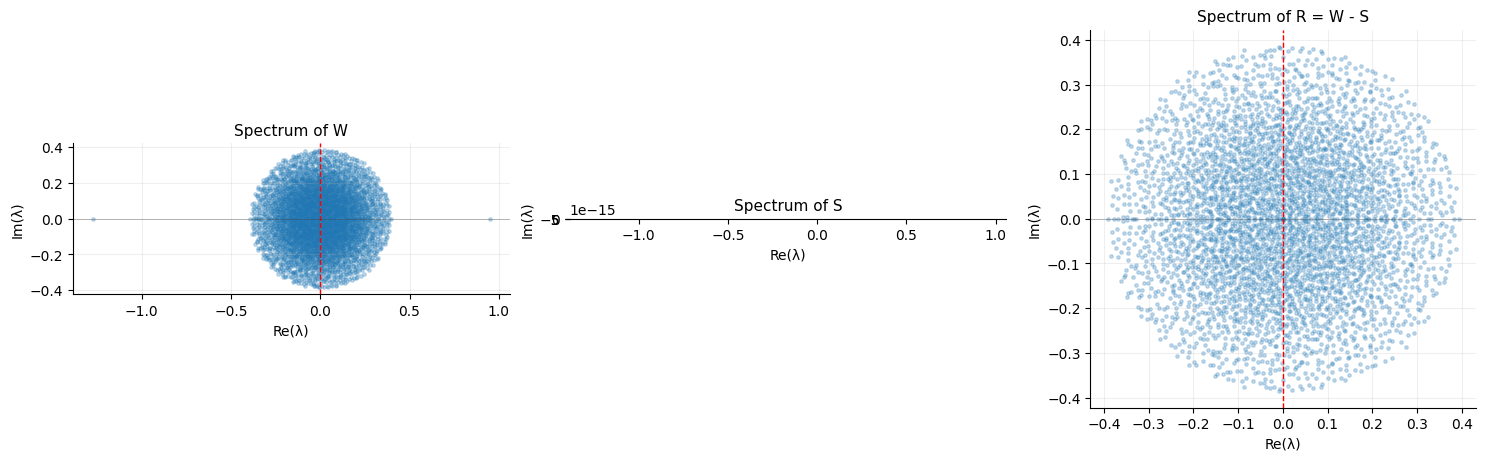

In [9]:
areas = (
    AreaParams(N=2000, s=0.05, f_exc=0.8, J_exc=0.0163, g_inh=4.5),
    AreaParams(N=2000, s=0.05, f_exc=0.8, J_exc=0.0163, g_inh=4.5),
)

A = len(areas)

s_cross = np.zeros((A, A))
J_cross = np.zeros((A, A))

s_cross[0, 1] = 0.025
J_cross[0, 1] = 0.0278

s_cross[1, 0] = 0.025
J_cross[1, 0] = 0.0278

p = MultiAreaParams(
    areas=areas,
    s_cross=s_cross,
    J_cross=J_cross,
    allow_autapses=False,
    activation="threshold_linear",
    phi_max=np.inf,
    gamma=0.5,
    dt=0.005,
    T=60.0,
    seed=1,)

W_base, meta = build_multi_area_connectivity(p)
print("Network meta:")
print("N_total =", meta["N_total"])
print("Fraction of non-zero entries =", meta["nnz"] / (meta["N_total"] * meta["N_total"]))

W_dense = W_base.toarray()
S_dense = build_mean_connectivity_dense(p)
R_dense = W_dense - S_dense

# ----- spectral quantities -----
eig_R = np.linalg.eigvals(R_dense)
eig_S = np.linalg.eigvals(S_dense)
eig_S_nonzero = eig_S[np.abs(eig_S) > 1e-6]

S_max_real_nonzero_eig = (
    float(np.max(eig_S_nonzero.real))
    if eig_S_nonzero.size > 0
    else 0.0
)

spec = analyze_WSR_spectra(W_base, p, zero_tol=1e-6)

print("max Re(lambda_W), |lambda| > 1e-6 =", spec["W_max_real_nonzero"])
print("max Re(lambda_S), |lambda| > 1e-6 =", spec["S_max_real_nonzero"])
print("max Re(lambda_R), |lambda| > 1e-6 =", spec["R_max_real_nonzero"])

fig, axes = plot_WSR_spectra(
    spec["eig_W"],
    spec["eig_S"],
    spec["eig_R"],
)
plt.show()